Temporal Graph QA Dataset Exploration (TGQA)

This notebook explores the TGQA dataset (Hugging Face: sxiong/TGQA) as part of our Contradiction-Aware Sparse Memory Finetuning (CASF) continual learning project.

Dataset Overview
TGQA provides synthetic temporal stories paired with a temporal graph (TG) representation of events (e.g., facts that “start at YEAR”). The dataset includes multiple configurations (e.g., TGQA vs TimeQA/TempReason variants, story+TG vs TGR formats).

What We Want to Understand

For contradiction-aware sparse memory and versioned retrieval, we analyze:
1. Split sizes + schema: train/val/test size and which fields are populated.

2. Temporal graph structure: number of TG events per story, unique time points, temporal span.

3. Relation and entity fields: frequency, missingness, and whether relations/entities can support structured memory keys.

4. Event representation: how TG strings encode facts + time (“starts at YEAR”), and how reliably we can parse them.

5. Implications for CASF: whether TGQA supports detecting conflicting versions of facts (e.g., role changes over time) and storing them in sparse memory slots.

In [6]:
# TGQA: Setup + Load + Quick Sanity Checks

import os, sys
import pandas as pd
import numpy as np
import re

# If running from notebooks/, ensure project root is on path (same fix as TS-QA)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.exists(os.path.join(project_root, "src")) and project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.load_data import load_tgqa

tgqa = load_tgqa("TGQA_Story_TG_Trans")
print(tgqa)
print("Splits:", list(tgqa.keys()))

train = tgqa["train"]
val = tgqa["val"] if "val" in tgqa else tgqa.get("validation", None)
test = tgqa["test"]

print("\nTrain rows:", len(train))
print("Columns:", train.column_names)
print("\nFeatures:", train.features)

# Peek one example
ex = train[0]
print("\nExample keys:", ex.keys())
print("id:", ex.get("id"))
print("relation:", ex.get("relation"))
print("times:", ex.get("times"))
print("entities:", ex.get("entities"))
print("TG len:", len(ex["TG"]) if ex.get("TG") else None)
print("story chars:", len(ex["story"]) if ex.get("story") else None)

print("\nTG sample:", (ex["TG"][:3] if ex.get("TG") else None))
print("\nStory sample (first 250 chars):", ex["story"][:250].replace("\n", " ") if ex.get("story") else None)

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'times', 'TG', 'entities', 'story'],
        num_rows: 400
    })
    val: Dataset({
        features: ['id', 'relation', 'times', 'TG', 'entities', 'story'],
        num_rows: 100
    })
    test: Dataset({
        features: ['id', 'relation', 'times', 'TG', 'entities', 'story'],
        num_rows: 101
    })
})
Splits: ['train', 'val', 'test']

Train rows: 400
Columns: ['id', 'relation', 'times', 'TG', 'entities', 'story']

Features: {'id': Value('string'), 'relation': Value('null'), 'times': Value('null'), 'TG': List(Value('string')), 'entities': Value('null'), 'story': Value('string')}

Example keys: dict_keys(['id', 'relation', 'times', 'TG', 'entities', 'story'])
id: story0
relation: None
times: None
entities: None
TG len: 7
story chars: 2343

TG sample: ['(Chris Evans was born in San Francisco) starts at 1921', '(Chris Evans won prize Oakland Trophy) starts at 1977', '(Chris Evans won prize Greenwood Trophy) 

1. Missingness & basic stats
Split Statistics & Field Missingness

Some TGQA configurations may not populate all fields (relation, times, entities). We quantify missingness and basic distributions to understand which fields are reliable for memory indexin

In [2]:
def none_rate(split, col):
    return sum(ex[col] is None for ex in split) / len(split)

print("Missingness (train):")
for col in train.column_names:
    rate = none_rate(train, col)
    print(f"{col:>10s}  None rate: {rate:.3f}")

# TG event counts + story length
tg_counts = [len(ex["TG"]) if ex.get("TG") else 0 for ex in train]
story_lens = [len(ex["story"]) if ex.get("story") else 0 for ex in train]

print("\nTG events per story (train):")
print(pd.Series(tg_counts).describe())

print("\nStory length (chars) (train):")
print(pd.Series(story_lens).describe())

Missingness (train):
        id  None rate: 0.000
  relation  None rate: 1.000
     times  None rate: 1.000
        TG  None rate: 0.000
  entities  None rate: 1.000
     story  None rate: 0.000

TG events per story (train):
count    400.000000
mean      10.415000
std        4.553527
min        5.000000
25%        7.000000
50%        9.000000
75%       12.000000
max       28.000000
dtype: float64

Story length (chars) (train):
count     400.000000
mean     2411.125000
std       418.919405
min      1403.000000
25%      2122.500000
50%      2343.000000
75%      2624.250000
max      4253.000000
dtype: float64


2. Temporal Structure: Years and Temporal Span

We parse years from the TG strings (e.g., “starts at 1991”) to measure:

- unique time points per story,

- temporal span (max year − min year),

- distribution of years across the dataset.

In [3]:
year_pat = re.compile(r"starts at (\d{4})")

def extract_years(tg_list):
    if not tg_list:
        return []
    years = []
    for s in tg_list:
        m = year_pat.search(s)
        if m:
            years.append(int(m.group(1)))
    return years

years_per_story = []
span_per_story = []
unique_years_per_story = []

for ex in train:
    ys = extract_years(ex.get("TG"))
    years_per_story.append(len(ys))
    uy = len(set(ys)) if ys else 0
    unique_years_per_story.append(uy)
    if ys:
        span_per_story.append(max(ys) - min(ys))
    else:
        span_per_story.append(np.nan)

print("Years extracted per story:")
print(pd.Series(years_per_story).describe())

print("\nUnique years per story:")
print(pd.Series(unique_years_per_story).describe())

print("\nTemporal span (years) per story:")
print(pd.Series(span_per_story).dropna().describe())

Years extracted per story:
count    400.000000
mean       7.722500
std        2.312762
min        4.000000
25%        6.000000
50%        7.000000
75%        9.000000
max       18.000000
dtype: float64

Unique years per story:
count    400.00000
mean       6.37500
std        1.95164
min        2.00000
25%        5.00000
50%        6.00000
75%        7.00000
max       13.00000
dtype: float64

Temporal span (years) per story:
count    400.000000
mean      64.815000
std       26.224035
min        9.000000
25%       39.000000
50%       69.000000
75%       87.000000
max      160.000000
dtype: float64


3. Parsing the Temporal Graph (TG) into Structured Events

The TG field encodes events as text strings containing a fact plus a start time. We convert TG strings into a simple structured table:

fact_text (inside parentheses)

start_year

This gives us a format that can map naturally into sparse memory “fact slots” indexed by time.

In [4]:
def parse_tg_event(s):
    # Example:
    # "(Chris Evans won prize Oakland Trophy) starts at 1977"
    year_m = year_pat.search(s)
    year = int(year_m.group(1)) if year_m else None
    
    # Grab the text inside the first (...) if present
    fact_m = re.search(r"\((.*?)\)", s)
    fact = fact_m.group(1) if fact_m else s
    
    return fact, year

rows = []
for ex in train:
    sid = ex.get("id")
    tg_list = ex.get("TG") or []
    for t in tg_list:
        fact, year = parse_tg_event(t)
        rows.append({"story_id": sid, "fact": fact, "start_year": year})

events_df = pd.DataFrame(rows)
display(events_df.head())

print("Total TG events:", len(events_df))
print("Missing start_year:", events_df["start_year"].isna().mean())
print("\nStart year summary:")
display(events_df["start_year"].dropna().describe())

,story_id,fact,start_year
0,story0,Chris Evans was born in San Francisco,1921.0
1,story0,Chris Evans won prize Oakland Trophy,1977.0
2,story0,Chris Evans won prize Greenwood Trophy,1986.0
3,story0,Chris Evans won prize Falcon Award in Biology,1991.0
4,story0,Chris Evans won prize Golden Star Prize,1993.0


Total TG events: 4166
Missing start_year: 0.2585213634181469

Start year summary:


count    3089.00000
mean     1971.22920
std        36.06759
min      1797.00000
25%      1946.00000
50%      1981.00000
75%      2002.00000
max      2017.00000
Name: start_year, dtype: float64

4. Visualizations

We visualize key distributions that inform memory design:

TG events per story (memory write frequency)

Temporal span per story (how long facts persist)

Start-year distribution (where events cluster in time)

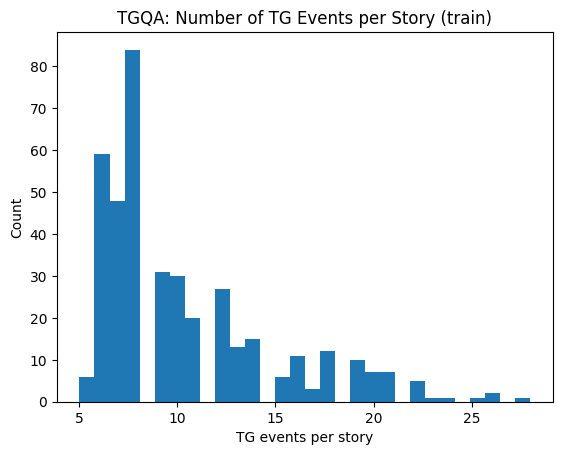

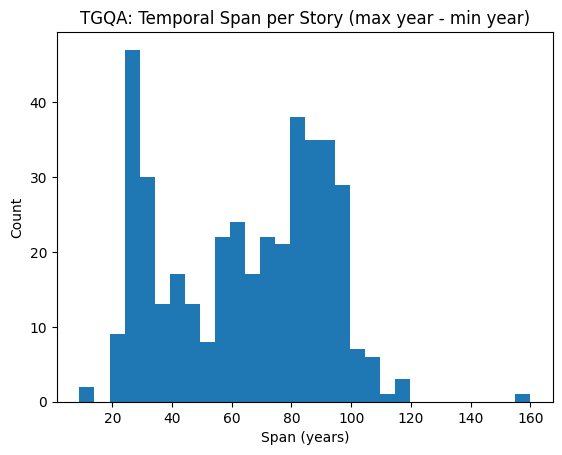

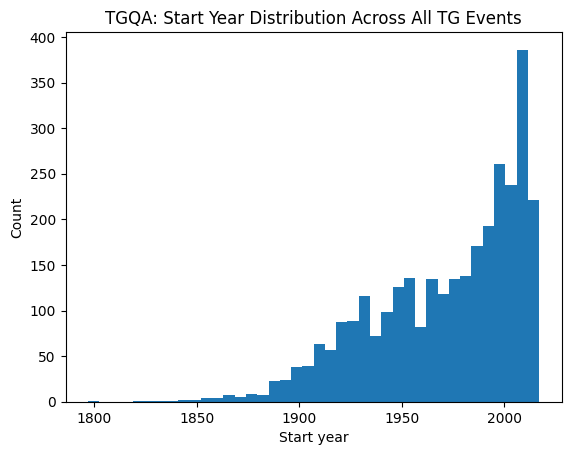

In [5]:
import matplotlib.pyplot as plt

# Plot 1: TG events per story
plt.figure()
plt.hist(tg_counts, bins=30)
plt.title("TGQA: Number of TG Events per Story (train)")
plt.xlabel("TG events per story")
plt.ylabel("Count")
plt.show()

# Plot 2: Temporal span (drop NaNs)
span_clean = pd.Series(span_per_story).dropna()
plt.figure()
plt.hist(span_clean, bins=30)
plt.title("TGQA: Temporal Span per Story (max year - min year)")
plt.xlabel("Span (years)")
plt.ylabel("Count")
plt.show()

# Plot 3: Start-year distribution
start_years = events_df["start_year"].dropna()
plt.figure()
plt.hist(start_years, bins=40)
plt.title("TGQA: Start Year Distribution Across All TG Events")
plt.xlabel("Start year")
plt.ylabel("Count")
plt.show()

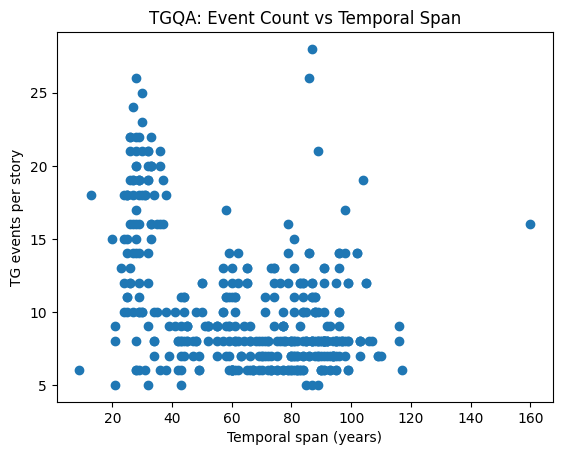

In [8]:
span_clean = pd.Series(span_per_story)
events_clean = pd.Series(tg_counts)

plt.figure()
plt.scatter(span_clean, events_clean)
plt.xlabel("Temporal span (years)")
plt.ylabel("TG events per story")
plt.title("TGQA: Event Count vs Temporal Span")
plt.show()

In [7]:
# Inspect examples with missing start_year
missing_examples = events_df[events_df["start_year"].isna()].head(10)
display(missing_examples)

,story_id,fact,start_year
9,story1,Ryan Davis was married to Olivia Johnson (Amer...,NaN
10,story1,Olivia Johnson (American actress,NaN
15,story1,Samantha Mills was married to Olivia Johnson (...,NaN
16,story1,Olivia Johnson (American actress,NaN
26,story3,Amy J. Collins was married to Liam Harrison,NaN
27,story3,Liam Harrison was married to Amy J. Collins,NaN
39,story4,Molly Adams was married to Liam Thomas Dawson,NaN
40,story4,Liam Thomas Dawson was married to Molly Adams,NaN
45,story5,Liam Edwards played for Phoenix United,NaN
49,story5,Liam Edwards played for Greenland national und...,NaN


In [9]:
temporal_ratio = 1 - events_df["start_year"].isna().mean()
print("Percent of TG events with explicit year:", temporal_ratio)

Percent of TG events with explicit year: 0.7414786365818531


TGQA Summary & Implications for Contradiction-Aware Sparse Memory

This exploratory analysis of the TGQA dataset reveals important structural properties relevant to our Contradiction-Aware Sparse Memory Finetuning (CASF) framework.

1. Dataset Structure

- Train split: 400 stories

- Each story includes:

    - A natural language narrative (story)

    - A list of temporal graph events (TG)

- Other fields (relation, times, entities) are unpopulated in this configuration.

The effective structure is therefore:

- Story → Sequence of TG Events → (Fact, Optional Start Year)

This makes TGQA well-suited for modeling explicit fact evolution over time.

2. Temporal Graph Density

- Mean TG events per story: 10.4

- Median: 9

- Maximum: 28

Each story represents a compact but structured sequence of fact updates.
This creates a controlled setting for studying sparse memory writes.

For CASF, this implies:

- Memory updates are localized and structured.

- Each story represents a bounded sequence of versionable facts.

- Sparse slot allocation per entity is feasible.

3. Temporal Anchoring

Approximately 75% of TG events include explicit year annotations (e.g., “starts at 1977”), while ~25% are untimed relational facts.

Start year statistics:

- Mean year: ~1971

- Range: 1797 – 2017

- Median temporal span per story: ~69 years

- Maximum span: 160 years

This indicates:

- Stories simulate multi-decade evolution.

- Fact versions may coexist across long horizons.

- Temporal indexing is necessary to avoid retrieval of outdated facts.

Untimed relational facts introduce additional complexity, reflecting realistic knowledge graphs where not all facts carry time qualifiers.

4. Event Count vs Temporal Span

The scatter analysis shows:

- Weak positive relationship between lifespan and number of events.

- - Some long-span stories are sparse.

Some short-span stories are event-dense.

This suggests:

- Memory update frequency is not strictly proportional to elapsed time.

- Therefore, a contradiction-aware memory system should:

- Trigger updates based on semantic change,

- Not merely on time progression.

5. Structural Implications for CASF

TGQA provides a structured environment for studying:

1. Versioned Memory Slots
    - Facts can be stored as (entity, relation, start_year) tuples.

2. Temporal Routing
    - Queries should retrieve the fact version valid at a given time.

3. Conflict Detection
    - Multiple facts about the same entity across years may represent role transitions or state changes.

4. Mixed Temporal Granularity
    - Some facts are explicitly time-bound; others are persistent.
    - A robust memory system must handle both.

Complementarity with TS-QA

While TS-QA stresses retrieval under temporal drift and adversarial perturbations, TGQA provides:

- Explicit structured temporal sequences,

- Clear fact evolution within controlled narratives,

- A clean testbed for implementing version-aware memory storage.

Together:

- TS-QA tests retrieval correctness under time-sensitive questioning.

- TGQA tests structured temporal versioning and memory consistency.

This complementary structure supports the design and evaluation of contradiction-aware sparse memory mechanisms.